# CSCA-5642, NLP with Disaster Tweets


# Brief description of the problem and data¶

In this notebook I’m training a few RNN models to predict which Tweets are about real disasters and which ones are not.

## Dataset

The dataset consists of two csv files: the labeled one used for model training and validation, and the unlabeled for prediction, for participating in the competition.
* **train.csv**: 7613 twits, 987712 B
* **test.csv**: 3263 twits, 420783 B

The columns in files:
* `id` - a unique identifier for each tweet
* `text` - the text of the tweet
* `location` - the location the tweet was sent from (may be blank)
* `keyword` - a particular keyword from the tweet (may be blank)
* `target` - in **train.csv** only, this denotes whether a tweet is about a real disaster (`1`) or not (`0`)

In [103]:
#!ls /kaggle/input/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
#!zip -r /kaggle/working/all-MiniLM-L6-v2.zip /kaggle/input/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
#!rm /kaggle/working/*.csv
#!rm /kaggle/working/*.keras

## Additional datasets/models

To jumpstart with pretrained embeddings I'm relying on two additional models:
* `glove-twitter-100d` - GloVe by Stanford for single word embeddings
* `all-MiniLM-L6-v2` - a sentence transformer by Microsoft Research/Hugging Face

## Additional python packages
* `contractions` - to expand English language contractions
* `spellchecker` - to correct very typos

In [1]:
DATASET_DIR = '/kaggle/input/nlp-getting-started'
GLOVE_EMB = '/kaggle/input/glove-twitter-100d/glove.twitter.27B.100d.txt'
MINILM_L6V2 = '/kaggle/input/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'
WORKING_DIR = '/kaggle/working/'

# Exploratory Data Analysis (EDA)

In [2]:
from os import path
import pandas as pd

train_df = pd.read_csv(path.join(DATASET_DIR, 'train.csv'))
test_df = pd.read_csv(path.join(DATASET_DIR, 'test.csv'))

In [3]:
train_df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


I don't plan any special handling of NaN, let's just impute empty strings to simplify the processing down the road.

In [4]:
train_df = train_df.fillna('')
test_df = test_df.fillna('')

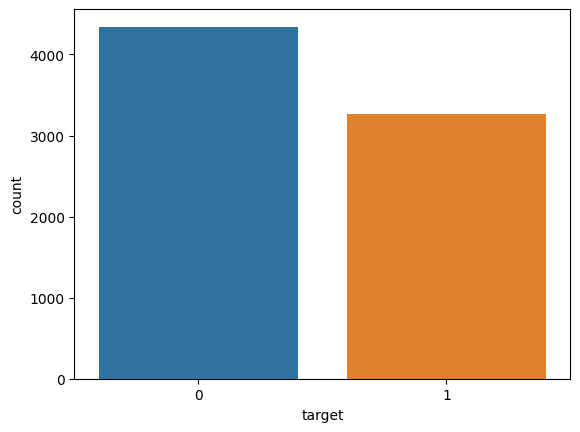

target==0: 4342
target==1: 3271


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='target', data=train_df)
plt.show()

print('target==0:', train_df[train_df['target']==0].shape[0])
print('target==1:', train_df[train_df['target']==1].shape[0])

Let's look at the basic tweets propoerties (not showing corresponding characteristics of test_df, but they have very similar distribution)

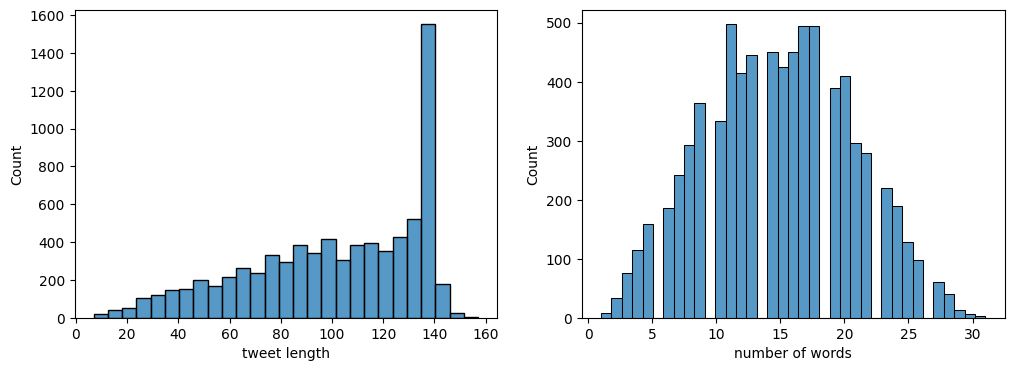

In [6]:
#import warnings
#warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.histplot(data=train_df['text'].apply(len), ax=axes[0])
axes[0].set_xlabel('tweet length')

sns.histplot(data=train_df['text'].apply(lambda t: len(t.split())), ax=axes[1])
axes[1].set_xlabel('number of words')

plt.show()

Let's take a look at some values in `keyword` and `location` columns. There are actually not too many different keywords, but much more distinct locations. The keywords are either single words or a short URI-encoded sentense like `bridge%20collapse`, locations are in free form, could be very specifil like longiture and latitude, could be not be a real location at all.

In [7]:
print('Unique keywords:', len(train_df['keyword'].unique()))
print('Unique locations:', len(train_df['location'].unique()))

train_df[train_df['id'].isin([563,974,1094,1702,2297,4847,10468])]

Unique keywords: 222
Unique locations: 3342


,id,keyword,location,text,target
389,563,arson,"Milwaukee, WI",Owner of Chicago-Area Gay Bar Admits to Arson ...,0
674,974,blaze,SOUTHERN CALIFORNIA DESERT,3 Bedrooms 1 Baths for sale in 29 Palms CA. (h...,0
758,1094,blew%20up,?205?478?,Max blew tf up ! ?????? shots fired ???? #Catf...,0
1182,1702,bridge%20collapse,UK,Australia's Ashes disaster - how the collapse ...,1
1590,2297,cliff%20fall,DRAW A CIRCLE THAT'S THE EARTH,*Jumps off of a cliff while drinking tea*\n\nT...,0
3385,4847,evacuation,"ÌÏT: 43.631838,-79.55807",INK Entertainment Addresses Veld Evacuation an...,0
7314,10468,wild%20fires,"Cedar Island, Clinton CT 06413",DEEP crew to help with California wild fires h...,1


Decoding the URI-encoding keywords now to simplify processing down the road

In [8]:
from urllib.parse import unquote
train_df['keyword'] = train_df['keyword'].apply(unquote)
test_df['keyword'] = test_df['keyword'].apply(unquote)

# Data Preprocessing

Since it's an NLP excersise, I'll be mostly focusing on training RNN layers on `text` column, and additionally trying to plug in `keyword` as another input.

1. LSTM (text)
2. GRU (text)
3. LSTM (text) + minilm (keyword)


## Normalizing texts

First of all, let's normalize the text:
*  expand English language contractions
*  run spellchecker and correct typos

In all the models `text` colmn first needs to be encoded to match the embedding level. 


Here I'm utilizing GloVe embeddings model and not training the embeddings layer. First of all, let's load embeddings and populate the embedding weights matrix.

In [9]:
!pip install pyspellchecker contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 55.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 6.6 MB/s eta 0:00:00


In [12]:
import re
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from spellchecker import SpellChecker

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
spell = SpellChecker(language='en', distance=1)

def try_correction(original):
    corrected = spell.correction(original)
    return corrected if corrected else original

def normalize(text):
    expanded_text = contractions.fix(text)
    tokens = word_tokenize(expanded_text)
    tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]
    tokens = [t.lower() for t in tokens if t]

    known_words = spell.known(tokens)
    tokens = [t if t in known_words else try_correction(t) for t in tokens]
    return ' '.join(tokens)

In [13]:
text = "I won't get oyt 'coz it's raining :<"
print(normalize(text))

i will not get out because it is raining


In [14]:
train_df['normalized'] = train_df['text'].apply(normalize)
test_df['normalized'] = test_df['text'].apply(normalize)

## Load GloVe and make embeddings

In [15]:
import numpy as np

def load_glove_embeddings(filepath):
    embedding_dict = {}
    with open(filepath, 'rt', encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            weights = np.asarray(values[1:],'float32')
            embedding_dict[word] = weights
    return embedding_dict

embedding_dict = load_glove_embeddings(GLOVE_EMB)

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(train_df['normalized'])
tokenizer.fit_on_texts(test_df['normalized'])

In [18]:
NUM_WORDS = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 100

embedding_matrix = np.zeros((NUM_WORDS, EMBEDDING_DIM))

for word, i in tokenizer.word_index.items():
    if word in embedding_dict:
        embedding_matrix[i] = embedding_dict[word]

The following embeddings layer will be shared across multiple models later in this section

In [20]:
from tensorflow.keras.layers import Embedding

shared_embeddings = Embedding(
    input_dim=NUM_WORDS, 
    output_dim=EMBEDDING_DIM, 
    weights=[embedding_matrix],
    trainable=False)

## Make sequences

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_LEN = 50  # From EDA we know that all the tweets are around 30 words long, but let's conservatively limit by 50 words

train_sequences = tokenizer.texts_to_sequences(train_df['normalized'])
test_sequences = tokenizer.texts_to_sequences(test_df['normalized'])

train_sequences_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, truncating='post', padding='post')
test_sequences_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, truncating='post', padding='post')

## MiniLM

In [23]:
from sentence_transformers import SentenceTransformer
sentence_transformer = SentenceTransformer(MINILM_L6V2)

keywords = list(set(train_df['keyword']) | set(test_df['keyword']))
sentence_transformer_encodings = sentence_transformer.encode(keywords)
keywords_to_encodings = dict(zip(keywords,sentence_transformer_encodings))

train_keyword_encodings = np.vstack(train_df['keyword'].map(keywords_to_encodings))
test_keyword_encodings = np.vstack(test_df['keyword'].map(keywords_to_encodings))

KEYWORD_VECTOR_DIM = train_keyword_encodings.shape[1]  # is 384 in MINILM_L6V2

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

# Model Architecture


* Tell why RNN
* Tell which hyperparameters were tuned manually


## LSTM

In [24]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dropout, LSTM, GRU, Dense, SpatialDropout1D, Concatenate, Input

def make_lstm_model(rnn_units=64):
    return Sequential([
        Input(shape=(MAX_LEN,)),
        shared_embeddings,
        SpatialDropout1D(0.2),
        LSTM(units=rnn_units, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid'),
    ])


model_lstm = make_lstm_model()
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     2,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,005 (9.90 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

## GRU

In [25]:
def make_gru_model(rnn_units=64):
    return Sequential([
        Input(shape=(MAX_LEN,)),
        shared_embeddings,
        SpatialDropout1D(0.2),
        GRU(units=rnn_units, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid'),
    ])
    
model_gru = make_gru_model()
model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     2,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,585,637 (9.86 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

## LSTM (text + keyword)

In [26]:
# Define and chain tensors explicitly

def make_lstm_kw_model(rnn_units=64, dense_units=64):

    text_input = Input(shape=(MAX_LEN,))
    text_emb = shared_embeddings(text_input)
    spatial_dropout = SpatialDropout1D(0.2)(text_emb)
    text_vector = LSTM(units=rnn_units, dropout=0.2, recurrent_dropout=0.2)(spatial_dropout)
    keyword_input = Input(shape=(KEYWORD_VECTOR_DIM,))
    
    combined_vector = Concatenate()([text_vector, keyword_input])
    hidden = Dense(units=dense_units, activation='relu')(combined_vector) 
    hidden = Dropout(0.5)(hidden)
    output = Dense(1, activation='sigmoid', name='output')(hidden)
    
    return Model(
        inputs=[text_input, keyword_input], 
        outputs=output
    )


model_lstm_kw = make_lstm_kw_model()
model_lstm_kw.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 100)   │  2,553,700 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 50, 100)   │          0 │ embedding_1[2][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     42,240 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 448)       │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     28,736 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,624,741 (10.01 MB)

 Trainable params: 71,041 (277.50 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

# Results and Analysis

In [27]:
from sklearn.model_selection import train_test_split

X_text = train_sequences_padded
X_keyword = train_keyword_encodings
y = train_df['target'].to_numpy().reshape(-1,1)


X_text_train, X_text_valid, X_keyword_train, X_keyword_valid, y_train, y_valid = train_test_split(
    X_text, X_keyword, y, test_size=0.2, random_state=5642, stratify=y)

print(X_text_train.shape, X_keyword_train.shape, y_train.shape)
print(X_text_valid.shape, X_keyword_valid.shape, y_valid.shape)

X_text_test = test_sequences_padded
X_keyword_test = test_keyword_encodings

print(X_text_test.shape, X_keyword_test.shape)

(6090, 50) (6090, 384) (6090, 1)
(1523, 50) (1523, 384) (1523, 1)
(3263, 50) (3263, 384)


In [28]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from os import listdir

result_df = test_df[['id']].copy()

def make_checkpoint_cb(model_name):
    model_file_path = path.join(WORKING_DIR, model_name
                                + '_epoch_{epoch:02d}'
                                + '_val_f1_score_{val_f1_score:.3f}'
                                + '_val_loss_{val_loss:.3f}.keras')
    return ModelCheckpoint(
        monitor='val_f1_score',
        mode='max',
        filepath=model_file_path,
        save_best_only=True,
        save_freq='epoch'
    )

def last_saved_model(name):
    all_files_sorted = sorted(listdir(WORKING_DIR))
    models = [f for f in all_files_sorted if f.startswith(name+'_') and f.endswith('.keras')]
    return path.join(WORKING_DIR, models[-1])


def predict_with_last_saved_model_save_csv(model_name, X_test):
    best_model_path = last_saved_model(model_name)
    model = load_model(best_model_path)
    
    y_pred = model.predict(X_test)
    result_df['target'] = tf.cast(tf.round(y_pred), tf.int32)
    
    best_model_path_no_ext, _ = path.splitext(best_model_path)
    best_model_result_csv = best_model_path_no_ext + '.csv'
    result_df.to_csv(best_model_result_csv, index=False)

    print(f'Saved to: {best_model_result_csv}')


In [29]:
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.optimizers import Adam

shared_metrics = ['binary_accuracy', 'auc', F1Score(threshold=0.5)]

## LSTM

In [28]:
model_lstm = make_lstm_model(rnn_units=64)
model_lstm.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_lstm = model_lstm.fit(X_text_train,y_train,
                              batch_size=512, epochs=100, verbose=0,
                              validation_data=(X_text_valid,y_valid),
                              callbacks=[make_checkpoint_cb('lstm')])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - auc: 0.5049 - binary_accuracy: 0.5390 - f1_score: 0.2260 - loss: 0.6929 - val_auc: 0.5006 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6921
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - auc: 0.5104 - binary_accuracy: 0.5675 - f1_score: 0.0000e+00 - loss: 0.6918 - val_auc: 0.5292 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6909
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - auc: 0.5077 - binary_accuracy: 0.5782 - f1_score: 0.0000e+00 - loss: 0.6905 - val_auc: 0.5275 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6895
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - auc: 0.5204 - binary_accuracy: 0.5764 - f1_score: 0.0000e+00 - loss: 0.6889 - val_auc: 0.5443 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6875
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - auc: 0.5282 - binary_accuracy: 0.5692 - f1_score:

## GRU

In [29]:
model_gru = make_gru_model(rnn_units=64)
model_gru.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_gru = model_gru.fit(X_text_train,y_train,
                            batch_size=512, epochs=100, verbose=0,
                            validation_data=(X_text_valid,y_valid),
                            callbacks=[make_checkpoint_cb('gru')])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - auc: 0.4996 - binary_accuracy: 0.5638 - f1_score: 0.3884 - loss: 0.6928 - val_auc: 0.5000 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6919
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - auc: 0.5014 - binary_accuracy: 0.5622 - f1_score: 0.0000e+00 - loss: 0.6918 - val_auc: 0.5000 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6907
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - auc: 0.4971 - binary_accuracy: 0.5670 - f1_score: 0.0000e+00 - loss: 0.6906 - val_auc: 0.5000 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6895
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - auc: 0.5056 - binary_accuracy: 0.5622 - f1_score: 0.0000e+00 - loss: 0.6896 - val_auc: 0.5000 - val_binary_accuracy: 0.5706 - val_f1_score: 0.0000e+00 - val_loss: 0.6882
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - auc: 0.4903 - binary_accuracy: 0.5750 - f1_score:

## LSTM (text + keyword)

In [31]:
model_lstm_kw = make_lstm_kw_model(rnn_units=64, dense_units=64)
model_lstm_kw.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_lstm_kw = model_lstm_kw.fit([X_text_train, X_keyword_train],y_train,
                                    batch_size=512, epochs=100, verbose=0,
                                    validation_data=([X_text_valid, X_keyword_valid],y_valid),
                                    callbacks=[make_checkpoint_cb('lstm-kw')])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - auc: 0.4931 - binary_accuracy: 0.4510 - f1_score: 0.5985 - loss: 0.7009 - val_auc: 0.5162 - val_binary_accuracy: 0.4235 - val_f1_score: 0.5787 - val_loss: 0.6974
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - auc: 0.5152 - binary_accuracy: 0.4639 - f1_score: 0.5478 - loss: 0.6973 - val_auc: 0.5513 - val_binary_accuracy: 0.4918 - val_f1_score: 0.5547 - val_loss: 0.6932
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - auc: 0.5451 - binary_accuracy: 0.5164 - f1_score: 0.5096 - loss: 0.6918 - val_auc: 0.5793 - val_binary_accuracy: 0.5896 - val_f1_score: 0.4726 - val_loss: 0.6894
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - auc: 0.5541 - binary_accuracy: 0.5459 - f1_score: 0.4398 - loss: 0.6890 - val_auc: 0.6155 - val_binary_accuracy: 0.5883 - val_f1_score: 0.3162 - val_loss: 0.6859
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - auc: 0.5756 - binary_accuracy: 0.5855 - f1_score: 0.3738 - loss: 0.6849 - val

In [33]:
predict_with_last_saved_model_save_csv('lstm', X_text_test)
predict_with_last_saved_model_save_csv('gru', X_text_test)
predict_with_last_saved_model_save_csv('lstm-kw', [X_text_test, X_keyword_test])

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Saved to: /kaggle/working/lstm_epoch_23_val_f1_score_0.756_val_loss_0.488.csv
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
Saved to: /kaggle/working/gru_epoch_89_val_f1_score_0.759_val_loss_0.485.csv
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
Saved to: /kaggle/working/lstm-kw_epoch_92_val_f1_score_0.762_val_loss_0.441.csv


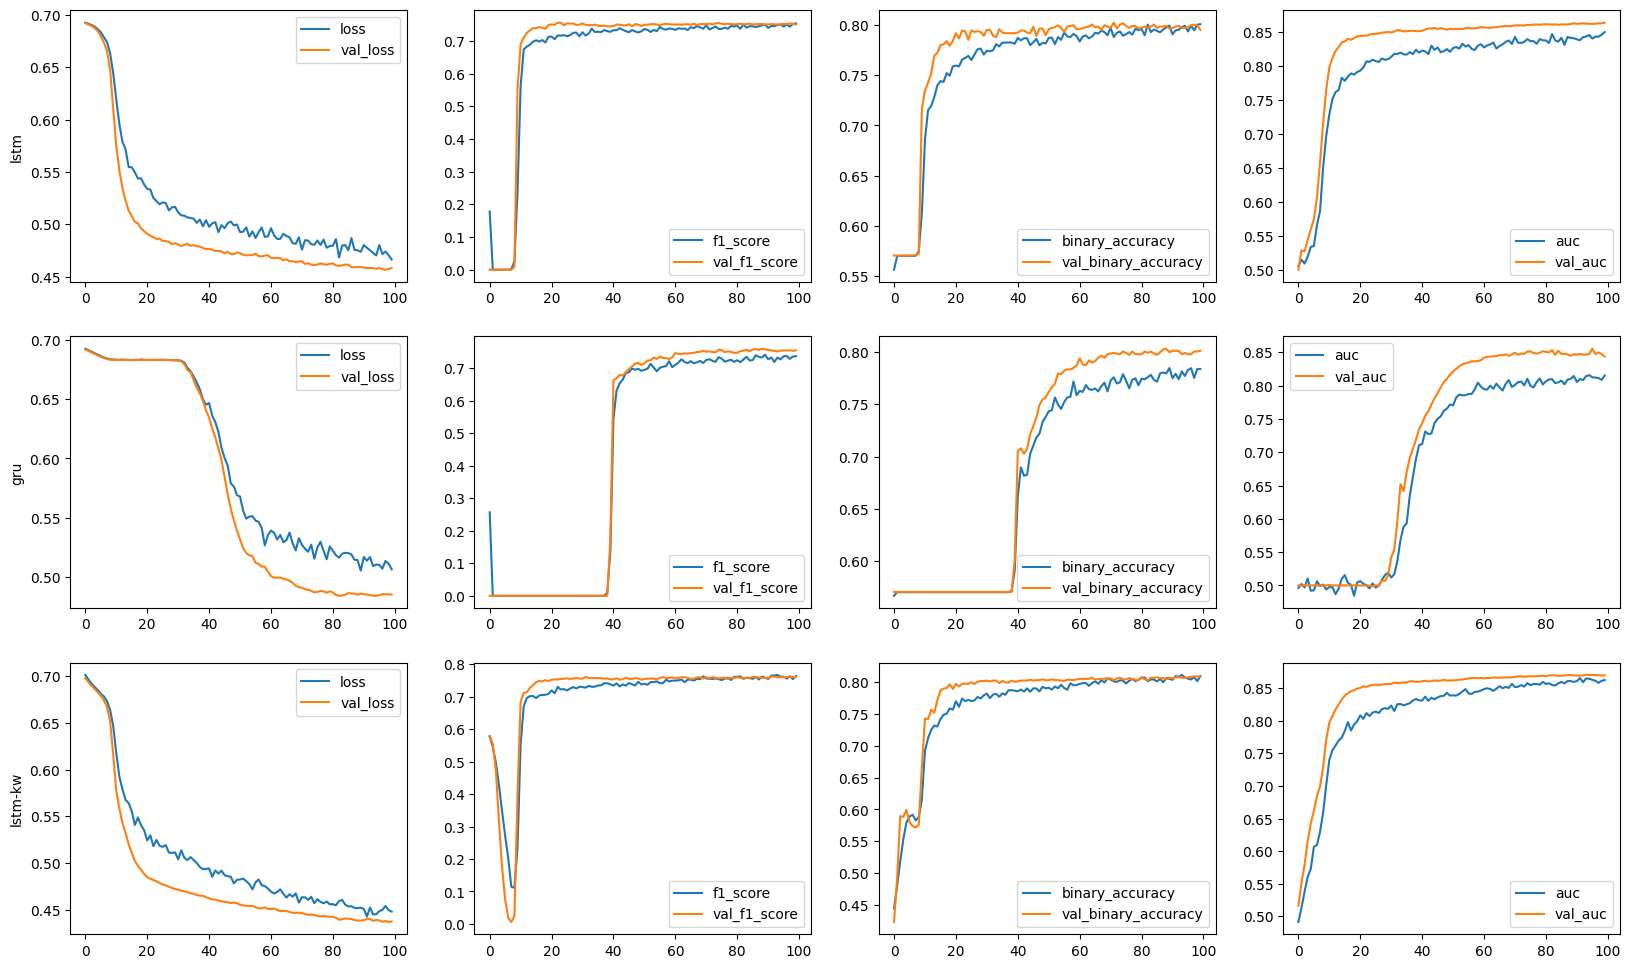

In [32]:
metrics = ['loss','f1_score','binary_accuracy','auc']
model_names = ['lstm', 'gru', 'lstm-kw']

stats = {
    'lstm': history_lstm.history,
    'gru': history_gru.history,
    'lstm-kw': history_lstm_kw.history
}


n = len(model_names)
m = len(metrics)

fig, axes = plt.subplots(n,m,figsize=(m*5,n*4))

for i,model_name in enumerate(model_names):
    for j,metric in enumerate(metrics):
        axes[i][0].set_ylabel(model_name)
        axes[i][j].plot(stats[model_name][metric], label=metric)
        axes[i][j].plot(stats[model_name]['val_'+metric], label='val_'+metric)
        axes[i][j].legend()
        

plt.show()

## Hyperparameters Tuning

In [33]:
from datetime import datetime

probe_rnn_units = [32, 64, 96]
probe_dense_units = [32, 64, 96]

histories = dict()

for ru in probe_rnn_units:
    for du in probe_dense_units:

        now_hms = datetime.now().strftime('%H:%M:%S')
        print(f'{now_hms} Starting {ru}-{du}')
        
        model_lstm_kw_tune = make_lstm_kw_model(rnn_units=ru, dense_units=du)
        model_lstm_kw_tune.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
        model_name = f'lstm-kw-ru{ru}-du{du}'

        history_lstm_kw_tune = model_lstm_kw_tune.fit(
            [X_text_train, X_keyword_train],y_train,
            batch_size=512, epochs=100, verbose=0,
            validation_data=([X_text_valid, X_keyword_valid],y_valid),
            callbacks=[make_checkpoint_cb(model_name)])
        histories[model_name] = history_lstm_kw_tune.history



07:17:42 Starting 32-32
07:19:40 Starting 32-64
07:21:37 Starting 32-96
07:23:35 Starting 64-32
07:26:52 Starting 64-64
07:30:11 Starting 64-96
07:33:33 Starting 96-32
07:38:03 Starting 96-64
07:42:35 Starting 96-96


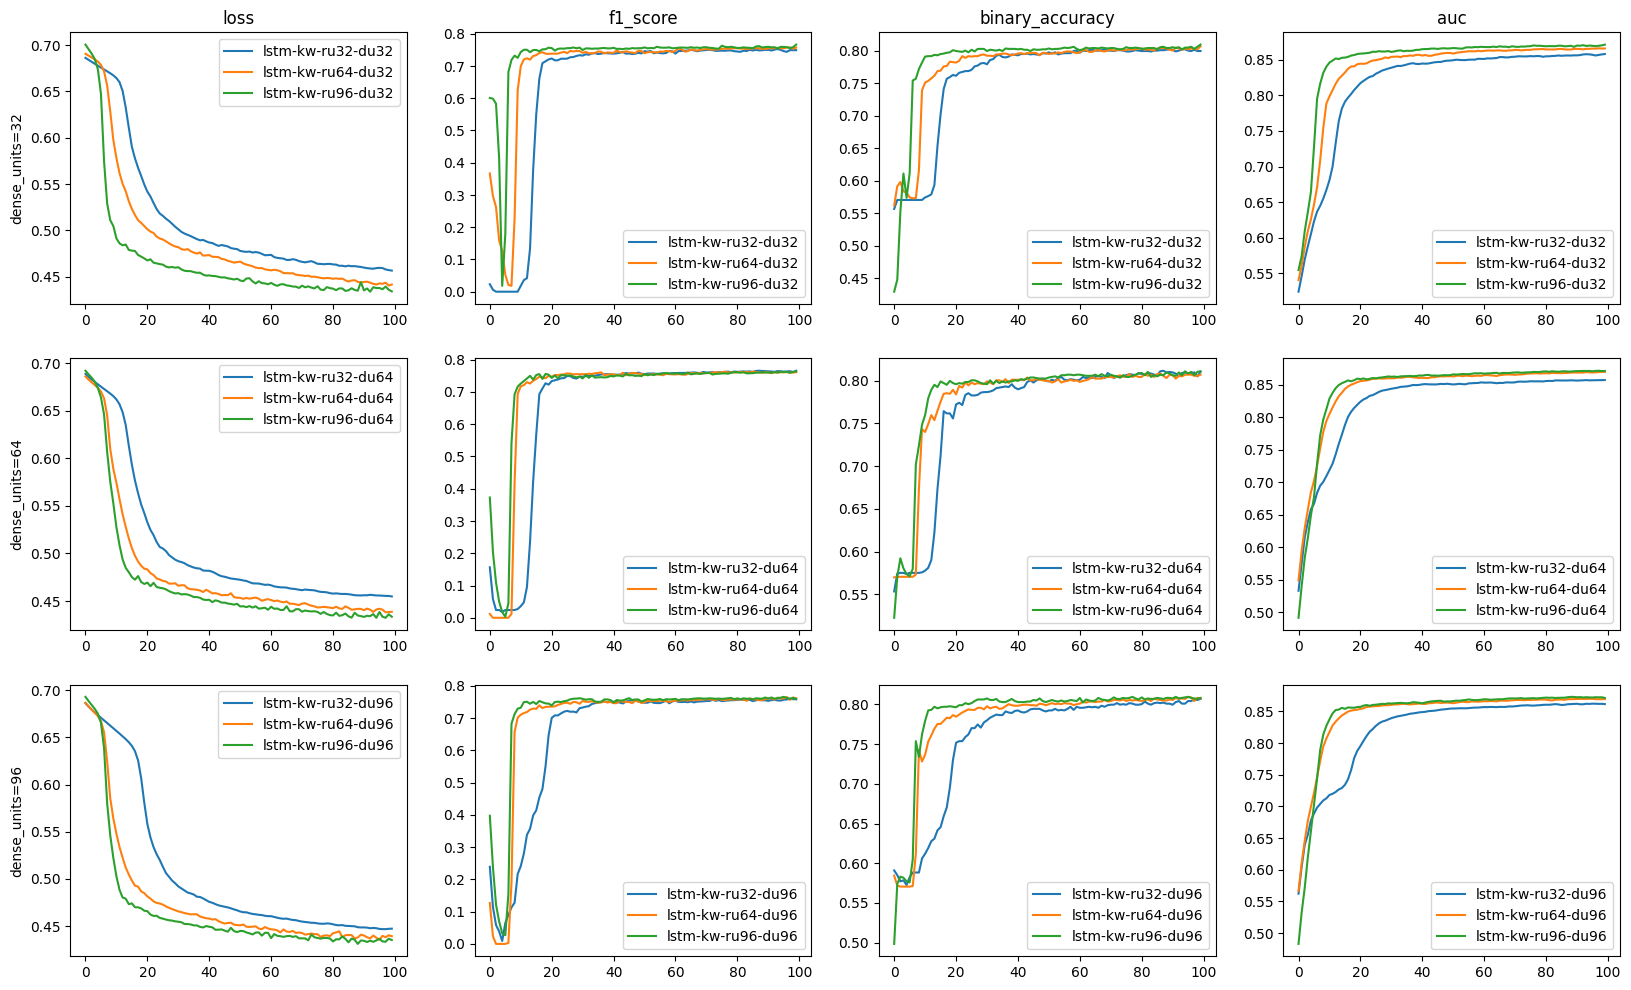

In [39]:
metrics = ['loss','f1_score','binary_accuracy','auc']

n = len(probe_dense_units)
m = len(metrics)

fig, axes = plt.subplots(n,m,figsize=(m*5,n*4))

for i,du in enumerate(probe_dense_units):
    axes[i][0].set_ylabel(f'dense_units={du}')
    
    for j,metric in enumerate(metrics):
        axes[0][j].set_title(metric)
        
        for ru in probe_rnn_units:
            model_name = f'lstm-kw-ru{ru}-du{du}'
            axes[i][j].plot(histories[model_name]['val_'+metric], label=model_name)
            
        axes[i][j].legend()
        
plt.show()

* Reason why something didn't work
* Toubleshooting
* Hyperparam optimization summary

# Conclusion

**DROPOUTS!**

* Basic reiteration of results

* Discussion of learning and takeaways

* Discussion of why something didn’t work.

* Suggestions for ways to improve. 

# ----------------------------------------------------------------------------------